# 01 · Exploring the ELPV Solar-Cell Dataset

This notebook is a guided tour of the data **before** we build any model. The goal is to
understand what we're working with: how many images there are, how balanced the two
classes are, what healthy vs. faulty cells actually look like, and whether the image
files on disk are real and uncorrupted.

We read everything from `data/labels_binary.csv`, which was produced by
`src/download_data.py`. Its columns are:

| column | meaning |
|--------|---------|
| `full_path` | absolute path to the cell image on disk |
| `label` | **0 = healthy**, **1 = faulty** |
| `probability` | the original ELPV defect probability (0.0, 0.3333, 0.6667, or 1.0) |

Run the cells top to bottom.

## 1. Imports

We only need a few libraries:

- **pandas** to load and slice the label table,
- **numpy** to inspect raw pixel values,
- **matplotlib** to draw the bar chart and the image grid,
- **PIL (Pillow)** to open the PNG images.

`Path` (from the standard library) lets us handle file paths cleanly.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Render plots inline in the notebook.
%matplotlib inline

## 2. Load the prepared label table

We load `data/labels_binary.csv` into a DataFrame. The notebook usually runs from the
`notebooks/` folder, so the file lives one level up at `../data/`; if you launched Jupyter
from the project root instead, we fall back to `data/`. Either way it just works.

`.head()` shows the first few rows and `.shape` tells us `(rows, columns)` — i.e. how many
images we have.

In [2]:
# Find the CSV whether the notebook is run from notebooks/ or the project root.
csv_path = Path("../data/labels_binary.csv")
if not csv_path.exists():
    csv_path = Path("data/labels_binary.csv")

df = pd.read_csv(csv_path)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (2624, 3)


,full_path,label,probability
0,/Users/richel/Documents/Reading the Grid/data/...,1,1.0
1,/Users/richel/Documents/Reading the Grid/data/...,1,1.0
2,/Users/richel/Documents/Reading the Grid/data/...,1,1.0
3,/Users/richel/Documents/Reading the Grid/data/...,0,0.0
4,/Users/richel/Documents/Reading the Grid/data/...,1,1.0


## 3. Class balance: healthy vs. faulty

Before training a classifier we need to know how many examples of each class we have. If
one class greatly outnumbers the other, plain accuracy becomes misleading (a model could
score well just by always predicting the majority class), and we'd need to account for
the imbalance during training.

Below we print the counts and percentages, then draw a simple bar chart.

healthy  (label 0):  1803 images  ( 68.7%)
faulty   (label 1):   821 images  ( 31.3%)
total               :  2624 images


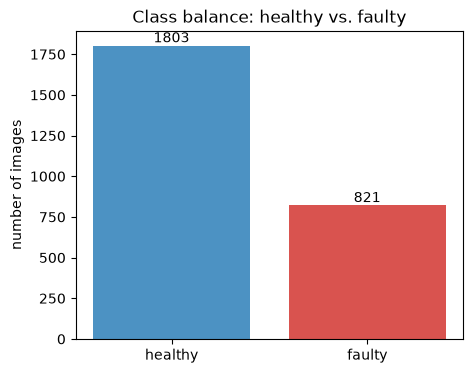

In [3]:
label_names = {0: "healthy", 1: "faulty"}
counts = df["label"].value_counts().sort_index()
percentages = df["label"].value_counts(normalize=True).sort_index() * 100

for label_value in counts.index:
    print(f"{label_names[label_value]:8s} (label {label_value}): "
          f"{counts[label_value]:5d} images  ({percentages[label_value]:5.1f}%)")
print(f"{'total':8s}            : {len(df):5d} images")

# Bar chart of the class counts.
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([label_names[i] for i in counts.index], counts.values,
       color=["#4c92c3", "#d9534f"])
ax.set_ylabel("number of images")
ax.set_title("Class balance: healthy vs. faulty")
for i, value in enumerate(counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.show()

## 4. A look at sample cells

Numbers only tell us so much — let's actually *see* the cells. We show two rows of five
images each: the top row is healthy cells, the bottom row is faulty cells. Each image is
titled with its label and the original defect probability.

We use a **grayscale colormap** because electroluminescence (EL) images are single-channel
intensity images — there is no real color information. We also fix the random seed so the
same examples appear every time you run the notebook (useful when teaching).

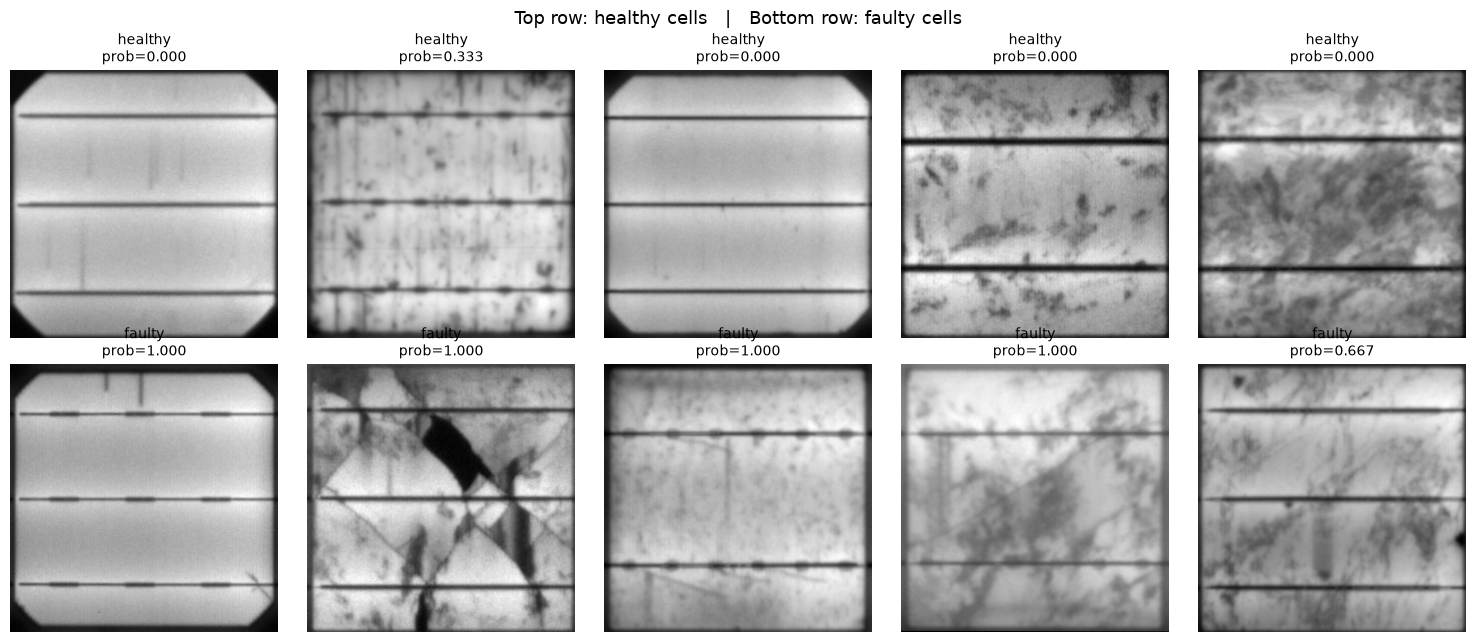

In [4]:
N_PER_ROW = 5

# Sample 5 of each class. random_state keeps the selection stable across runs.
healthy_samples = df[df["label"] == 0].sample(N_PER_ROW, random_state=0)
faulty_samples = df[df["label"] == 1].sample(N_PER_ROW, random_state=0)

fig, axes = plt.subplots(2, N_PER_ROW, figsize=(15, 6.5))

for row, (row_title, samples) in enumerate(
        [("healthy", healthy_samples), ("faulty", faulty_samples)]):
    for col, (_, record) in enumerate(samples.iterrows()):
        # Open as grayscale ("L" mode) and display with a gray colormap.
        img = Image.open(record["full_path"]).convert("L")
        ax = axes[row, col]
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{row_title}\nprob={record['probability']:.3f}", fontsize=10)
        ax.axis("off")

fig.suptitle("Top row: healthy cells   |   Bottom row: faulty cells", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Image sanity checks

Finally, we confirm the image files are genuine. We expect each to be roughly a
**300×300 grayscale** PNG with pixel values spanning the 0–255 range. We also print each
file's **size in kilobytes**: a real PNG is tens of kB, whereas a Git-LFS pointer or a
broken placeholder would only be a few hundred *bytes*. This catches corrupt or
not-actually-downloaded files before they cause confusing errors during training.

In [5]:
# Inspect a handful of images spread across the dataset.
sample_paths = df["full_path"].iloc[[0, len(df) // 2, len(df) - 1]].tolist()

for path in sample_paths:
    p = Path(path)
    img = Image.open(p)
    arr = np.asarray(img)
    size_kb = p.stat().st_size / 1024
    print(f"{p.name}: size={img.size}  mode={img.mode}  "
          f"pixel range=[{arr.min()}, {arr.max()}]  file={size_kb:6.1f} kB")

# A quick assertion makes the expectation explicit and fails loudly if it's violated.
first = Image.open(sample_paths[0])
assert first.size == (300, 300), f"Unexpected image size: {first.size}"
print("\nAll checks passed: images are real 300x300 PNGs, not placeholders.")

cell0001.png: size=(300, 300)  mode=L  pixel range=[4, 98]  file=  22.7 kB
cell1313.png: size=(300, 300)  mode=L  pixel range=[77, 173]  file=  31.0 kB
cell2624.png: size=(300, 300)  mode=L  pixel range=[41, 204]  file=  37.3 kB

All checks passed: images are real 300x300 PNGs, not placeholders.


## 6. Summary — key takeaways

- **Size:** the dataset has **2,624** EL solar-cell images, each a **300×300 grayscale** PNG.
- **Imbalance:** the classes are **not** balanced — about **69% healthy (0)** vs. **31% faulty (1)**.
  Roughly two out of three cells are healthy, so during training we should prefer
  precision/recall/F1 over raw accuracy and consider a class-weighted loss.
- **What faulty looks like:** healthy cells show a fairly uniform, even glow. Faulty cells
  show **dark regions, cracks, or disconnected ("dead") areas** where the cell does not
  light up — these dark patterns are the visual cues the CNN will learn to detect, and
  exactly what the Grad-CAM heatmap should highlight later.
- **Data integrity:** the sampled files are genuine PNGs (tens of kB, full 0–255 pixel
  range), so the dataset downloaded correctly and is ready for modeling.

Next step: build a PyTorch `Dataset`/`DataLoader` and train the classifier.